In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os

conn = sqlite3.connect('instacart.db')
os.makedirs('exports', exist_ok=True)
print("Ready!")

Ready!


In [3]:
reorder = pd.read_sql("""
    SELECT
        p.product_name,
        d.department,
        COUNT(*) AS total_orders,
        SUM(op.reordered) AS reorders,
        ROUND(100.0 * SUM(op.reordered) / COUNT(*), 1) AS reorder_pct
    FROM order_products_prior op
    JOIN products p ON op.product_id = p.product_id
    JOIN departments d ON p.department_id = d.department_id
    GROUP BY p.product_name, d.department
    HAVING total_orders > 500
    ORDER BY reorder_pct DESC
    LIMIT 50
""", conn)

print(reorder.head(10))
reorder.to_excel('exports/reorder_analysis.xlsx', index=False)
print("✓ Saved reorder_analysis.xlsx")

                      product_name  department  total_orders  reorders   
0  Half And Half Ultra Pasteurized  dairy eggs          2921      2517  \
1       Whole Organic Omega 3 Milk  dairy eggs          9108      7835   
2  Organic Lactose Free Whole Milk  dairy eggs          8477      7282   
3   Organic Homogenized Whole Milk  dairy eggs          3970      3405   
4             Ultra-Purified Water   beverages          1489      1277   
5         Milk, Organic, Vitamin D  dairy eggs         20198     17256   
6         Organic Reduced Fat Milk  dairy eggs         35663     30338   
7                        Goat Milk  dairy eggs          5185      4407   
8                           Banana     produce        472565    398609   
9              Organic  Whole Milk  dairy eggs          9842      8279   

   reorder_pct  
0         86.2  
1         86.0  
2         85.9  
3         85.8  
4         85.8  
5         85.4  
6         85.1  
7         85.0  
8         84.4  
9         84.1 

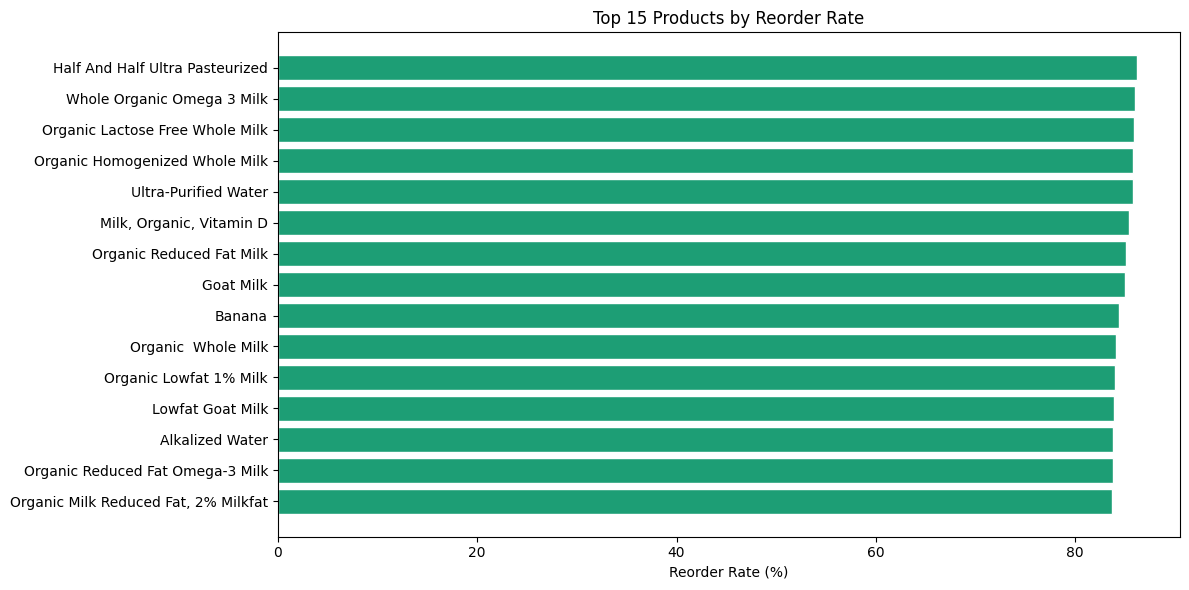

In [5]:
top15 = reorder.head(15)

plt.figure(figsize=(12, 6))
bars = plt.barh(top15['product_name'], top15['reorder_pct'], 
                color='#1D9E75', edgecolor='white')
plt.xlabel('Reorder Rate (%)')
plt.title('Top 15 Products by Reorder Rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('exports/04_top_reorder_products.png', dpi=150)
plt.show()

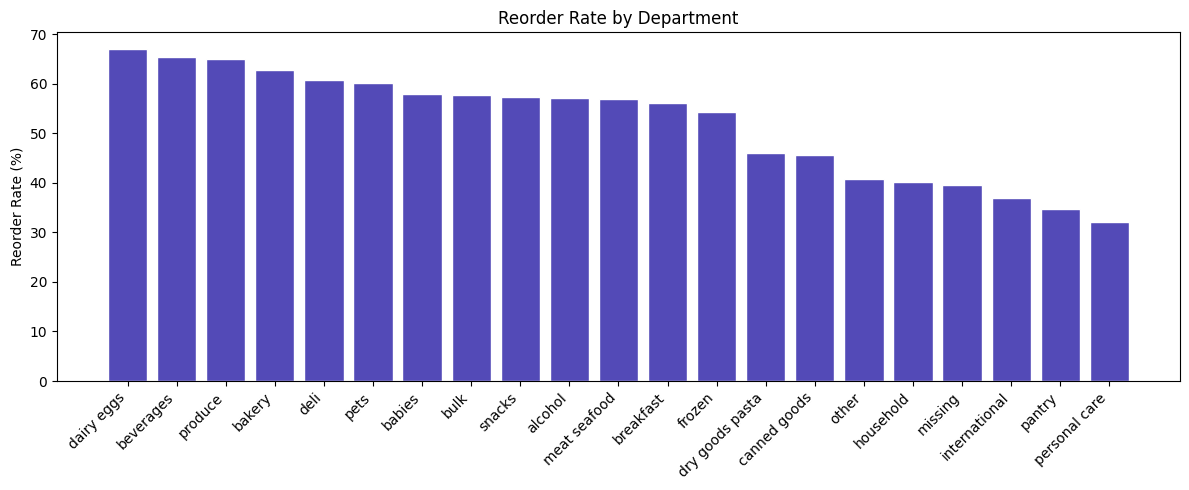

✓ Saved dept_reorder.xlsx


In [6]:
dept_reorder = pd.read_sql("""
    SELECT
        d.department,
        COUNT(*) AS total_orders,
        ROUND(100.0 * SUM(op.reordered) / COUNT(*), 1) AS reorder_pct
    FROM order_products_prior op
    JOIN products p ON op.product_id = p.product_id
    JOIN departments d ON p.department_id = d.department_id
    GROUP BY d.department
    ORDER BY reorder_pct DESC
""", conn)

plt.figure(figsize=(12, 5))
plt.bar(dept_reorder['department'], dept_reorder['reorder_pct'],
        color='#534AB7', edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Reorder Rate (%)')
plt.title('Reorder Rate by Department')
plt.tight_layout()
plt.savefig('exports/05_dept_reorder_rate.png', dpi=150)
plt.show()

dept_reorder.to_excel('exports/dept_reorder.xlsx', index=False)
print("✓ Saved dept_reorder.xlsx")

Basket size stats:
count    3214874.0
mean          10.1
std            7.5
min            1.0
25%            5.0
50%            8.0
75%           14.0
max          145.0
Name: basket_size, dtype: float64


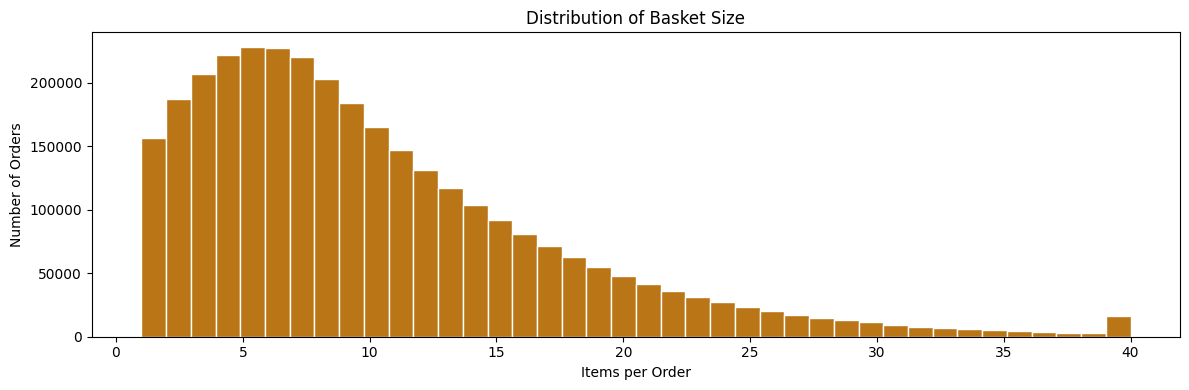

✓ Saved basket_stats.xlsx


In [4]:
basket_stats = pd.read_sql("""
    SELECT
        o.order_id,
        o.order_dow,
        o.order_hour_of_day,
        COUNT(op.product_id) AS basket_size
    FROM orders o
    JOIN order_products_prior op ON o.order_id = op.order_id
    GROUP BY o.order_id, o.order_dow, o.order_hour_of_day
""", conn)

print("Basket size stats:")
print(basket_stats['basket_size'].describe().round(1))

plt.figure(figsize=(12, 4))
basket_stats['basket_size'].clip(upper=40).plot(
    kind='hist', bins=40, color='#BA7517', edgecolor='white')
plt.xlabel('Items per Order')
plt.ylabel('Number of Orders')
plt.title('Distribution of Basket Size')
plt.tight_layout()
plt.savefig('exports/06_basket_size_dist.png', dpi=150)
plt.show()

rows_per_sheet = 1_000_000

with pd.ExcelWriter('exports/basket_stats.xlsx', engine='openpyxl') as writer:
    for i in range(0, len(basket_stats), rows_per_sheet):
        basket_stats.iloc[i:i + rows_per_sheet].to_excel(
            writer,
            sheet_name=f'Part_{i//rows_per_sheet + 1}',
            index=False
        )

print("✓ Saved basket_stats.xlsx")

In [5]:
# Install mlxtend first — run this once
import subprocess
subprocess.run(['pip', 'install', 'mlxtend'], capture_output=True)
print("mlxtend ready")

mlxtend ready


In [6]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Sample 30K orders (full dataset too large for RAM)
sample_orders = pd.read_sql("""
    SELECT op.order_id, p.product_name
    FROM order_products_prior op
    JOIN products p ON op.product_id = p.product_id
    WHERE op.order_id IN (
        SELECT DISTINCT order_id 
        FROM order_products_prior 
        LIMIT 30000
    )
""", conn)

print(f"Sampled {sample_orders['order_id'].nunique():,} orders")

# Convert to transaction format
baskets = sample_orders.groupby('order_id')['product_name'].apply(list).tolist()
te = TransactionEncoder()
te_array = te.fit_transform(baskets)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"Matrix shape: {df_encoded.shape}")
print("Running Apriori... (takes 2-3 mins)")

# Mine frequent itemsets
frequent = apriori(df_encoded, min_support=0.01, use_colnames=True, verbose=1)
rules = association_rules(frequent, metric='lift', min_threshold=1.5)
rules = rules.sort_values('lift', ascending=False)

print(f"\n✓ Found {len(rules)} association rules")
print(rules[['antecedents','consequents','support','confidence','lift']].head(10))

# Save top rules
rules_export = rules.head(50).copy()
rules_export['antecedents'] = rules_export['antecedents'].astype(str)
rules_export['consequents'] = rules_export['consequents'].astype(str)
rules_export.to_excel('exports/association_rules.xlsx', index=False)
print("✓ Saved association_rules.xlsx")

Sampled 30,000 orders
Matrix shape: (30000, 24905)
Running Apriori... (takes 2-3 mins)
Processing 21 combinations | Sampling itemset size 3e 2

✓ Found 24 association rules
                            antecedents                          consequents  \
5   frozenset({Bag of Organic Bananas})     frozenset({Organic Raspberries})   
4      frozenset({Organic Raspberries})  frozenset({Bag of Organic Bananas})   
14                  frozenset({Banana})      frozenset({Organic Fuji Apple})   
15      frozenset({Organic Fuji Apple})                  frozenset({Banana})   
23    frozenset({Organic Strawberries})    frozenset({Organic Hass Avocado})   
22    frozenset({Organic Hass Avocado})    frozenset({Organic Strawberries})   
2     frozenset({Organic Hass Avocado})  frozenset({Bag of Organic Bananas})   
3   frozenset({Bag of Organic Bananas})    frozenset({Organic Hass Avocado})   
8                   frozenset({Banana})          frozenset({Cucumber Kirby})   
9           frozenset({Cucu

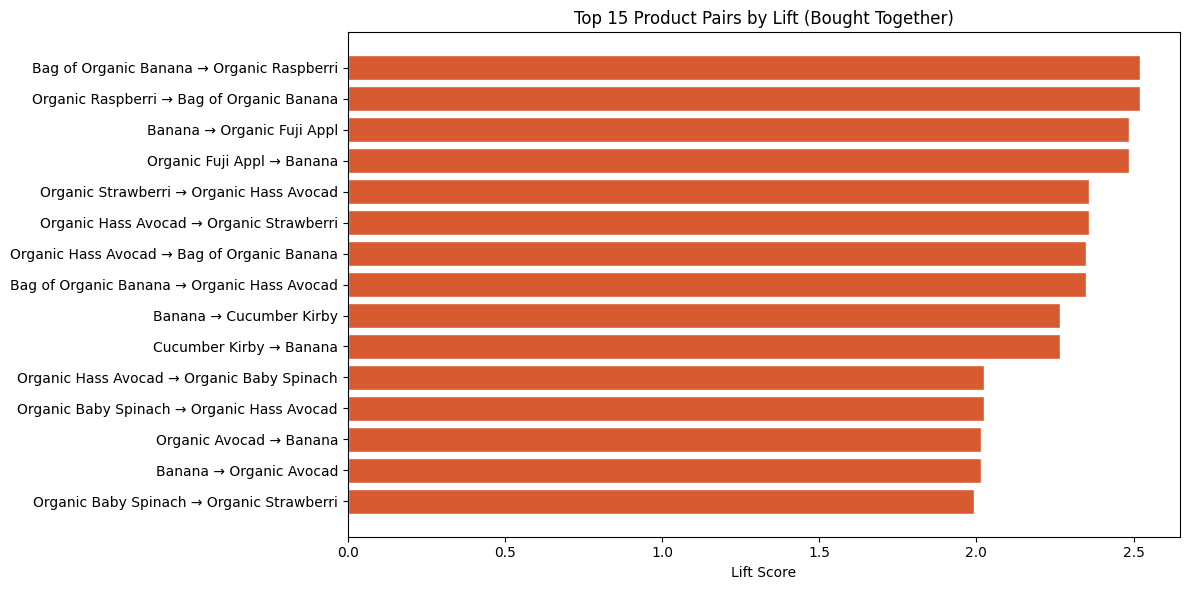

In [7]:
top_rules = rules.head(15).copy()
top_rules['pair'] = (top_rules['antecedents'].astype(str).str.strip("frozenset({'})") 
                     + ' → ' + 
                     top_rules['consequents'].astype(str).str.strip("frozenset({'})"))

plt.figure(figsize=(12, 6))
plt.barh(top_rules['pair'], top_rules['lift'], color='#D85A30', edgecolor='white')
plt.xlabel('Lift Score')
plt.title('Top 15 Product Pairs by Lift (Bought Together)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('exports/07_association_rules.png', dpi=150)
plt.show()